# VisionInspect — 01 Dataset Inventory (Updated)

Inventory and validate the raw industrial segmentation datasets before converting masks to YOLO segmentation labels.

**Datasets:** DAGM, KolektorSDD2, Magnetic Tile

The raw datasets are not modified. This notebook discovers image/mask pairs, distinguishes normal samples from genuinely missing annotations where appropriate, checks dimensions and mask statistics, analyzes contour complexity, and records DAGM difficulty metadata.

## Expected raw directory structures

### DAGM
```text
DAGM/
├── Class1/
│   ├── Train/
│   │   ├── Label/
│   │   └── *.PNG
│   └── Test/
│       ├── Label/
│       └── *.PNG
└── Class10/
```

### KolektorSDD2
```text
KolektorSDD2/
├── train/
│   ├── 10000.png
│   ├── 10000_GT.png
│   └── ...
└── test/
```

### Magnetic Tile
```text
magnetic_tile/
├── MT_Blowhole/Imgs/
├── MT_Break/Imgs/
├── MT_Crack/Imgs/
├── MT_Fray/Imgs/
├── MT_Uneven/Imgs/
└── MT_Free/Imgs/
```

For Magnetic Tile, the image is `.jpg` and the corresponding mask is the same basename with `.png`.

In [16]:
# Core imports
from pathlib import Path
from collections import Counter
import random

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print('OpenCV:', cv2.__version__)
print('NumPy:', np.__version__)
print('Pandas:', pd.__version__)

OpenCV: 5.0.0
NumPy: 2.5.1
Pandas: 3.0.5


## 1. Configure dataset paths

Change only these three paths. The notebook does not download or modify the datasets.

In [17]:
# Example for Google Drive in Colab:
# from google.colab import drive
# drive.mount('/content/drive')

DATA_ROOT = Path('datasets')

DAGM_ROOT = DATA_ROOT / 'DAGM'
KOLEKTOR_ROOT = DATA_ROOT / 'KolektorSDD2'
MAGNETIC_ROOT = DATA_ROOT / 'magnetic_tile'

for name, path in {
    'DAGM': DAGM_ROOT,
    'KolektorSDD2': KOLEKTOR_ROOT,
    'Magnetic Tile': MAGNETIC_ROOT,
}.items():
    print(f'{name:16s}: {path} | exists={path.exists()}')

DAGM            : datasets/DAGM | exists=True
KolektorSDD2    : datasets/KolektorSDD2 | exists=True
Magnetic Tile   : datasets/magnetic_tile | exists=True


In [18]:
IMAGE_EXTENSIONS = {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'}

def read_image(path, grayscale=False):
    flag = cv2.IMREAD_GRAYSCALE if grayscale else cv2.IMREAD_COLOR
    image = cv2.imread(str(path), flag)
    if image is None:
        raise ValueError(f'Could not read image: {path}')
    if not grayscale:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    return image

def mask_statistics(mask_path):
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return {
            'mask_readable': False,
            'mask_shape': None,
            'mask_unique_values': None,
            'foreground_pixels': None,
            'foreground_ratio': None,
            'is_empty': None,
            'num_contours': None,
        }

    binary = (mask > 0).astype(np.uint8)
    contours, _ = cv2.findContours(
        binary,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE,
    )

    foreground = int(binary.sum())
    total = int(binary.size)

    return {
        'mask_readable': True,
        'mask_shape': tuple(mask.shape),
        'mask_unique_values': np.unique(mask).tolist(),
        'foreground_pixels': foreground,
        'foreground_ratio': foreground / total if total else 0.0,
        'is_empty': foreground == 0,
        'num_contours': len(contours),
    }

## 2. DAGM discovery

The class ID is derived from `Class1` ... `Class10`. Images are expected directly under `Train` / `Test`, while masks are under `Label`.

In [30]:
def discover_dagm(root):
    records = []

    for class_dir in sorted(root.glob('Class*')):
        if not class_dir.is_dir():
            continue

        try:
            class_id = int(class_dir.name.replace('Class', '')) - 1
        except ValueError:
            continue

        for split_dir in [class_dir / 'Train', class_dir / 'Test']:
            if not split_dir.exists():
                continue

            mask_dir = split_dir / 'Label'

            for image_path in sorted(split_dir.iterdir()):
                if not image_path.is_file():
                    continue
                if image_path.suffix.lower() not in IMAGE_EXTENSIONS:
                    continue
                if image_path.parent.name.lower() == 'label':
                    continue

                candidate_mask_names = [
                    image_path.name,
                    f'{image_path.stem}_label{image_path.suffix}',
                ]
                mask_path = next(
                    (mask_dir / name for name in candidate_mask_names if (mask_dir / name).exists()),
                    mask_dir / candidate_mask_names[-1],
                )

                records.append({
                    'dataset': 'DAGM',
                    'source_class': class_dir.name,
                    'class_id': class_id,
                    'split': split_dir.name.lower(),
                    'image_path': image_path,
                    'mask_path': mask_path,
                    'mask_exists': mask_path.exists(),
                })

    return pd.DataFrame(records)

dagm_df = discover_dagm(DAGM_ROOT)
print(f'DAGM records: {len(dagm_df):,}')
display(dagm_df.head())

DAGM records: 16,100


,dataset,source_class,class_id,split,image_path,mask_path,mask_exists
0,DAGM,Class1,0,train,datasets/DAGM/Class1/Train/0576.PNG,datasets/DAGM/Class1/Train/Label/0576_label.PNG,False
1,DAGM,Class1,0,train,datasets/DAGM/Class1/Train/0577.PNG,datasets/DAGM/Class1/Train/Label/0577_label.PNG,False
2,DAGM,Class1,0,train,datasets/DAGM/Class1/Train/0578.PNG,datasets/DAGM/Class1/Train/Label/0578_label.PNG,False
3,DAGM,Class1,0,train,datasets/DAGM/Class1/Train/0579.PNG,datasets/DAGM/Class1/Train/Label/0579_label.PNG,False
4,DAGM,Class1,0,train,datasets/DAGM/Class1/Train/0580.PNG,datasets/DAGM/Class1/Train/Label/0580_label.PNG,False


## 3. KolektorSDD2 discovery

The pairing rule is `image.png` ↔ `image_GT.png`. Files containing `_GT` are treated as masks and are never treated as input images.

In [31]:
def discover_kolektor(root):
    records = []

    for split_name in ['train', 'test']:
        split_dir = root / split_name
        if not split_dir.exists():
            continue

        for image_path in sorted(split_dir.iterdir()):
            if not image_path.is_file():
                continue
            if image_path.suffix.lower() not in IMAGE_EXTENSIONS:
                continue
            if '_GT' in image_path.stem:
                continue

            mask_path = image_path.with_name(
                f'{image_path.stem}_GT{image_path.suffix}'
            )

            # KolektorSDD2 is inspected first as a binary defect-region
            # segmentation dataset. Any semantic subclass information
            # should be established from the actual dataset metadata,
            # not inferred from filenames.
            records.append({
                'dataset': 'KolektorSDD2',
                'source_class': 'defect_region',
                'class_id': 0,
                'split': split_name,
                'image_path': image_path,
                'mask_path': mask_path,
                'mask_exists': mask_path.exists(),
            })

    return pd.DataFrame(records)

kolektor_df = discover_kolektor(KOLEKTOR_ROOT)
print(f'KolektorSDD2 records: {len(kolektor_df):,}')
display(kolektor_df.head())

KolektorSDD2 records: 3,336


,dataset,source_class,class_id,split,image_path,mask_path,mask_exists
0,KolektorSDD2,defect_region,0,train,datasets/KolektorSDD2/train/10000.png,datasets/KolektorSDD2/train/10000_GT.png,True
1,KolektorSDD2,defect_region,0,train,datasets/KolektorSDD2/train/10001.png,datasets/KolektorSDD2/train/10001_GT.png,True
2,KolektorSDD2,defect_region,0,train,datasets/KolektorSDD2/train/10002.png,datasets/KolektorSDD2/train/10002_GT.png,True
3,KolektorSDD2,defect_region,0,train,datasets/KolektorSDD2/train/10003.png,datasets/KolektorSDD2/train/10003_GT.png,True
4,KolektorSDD2,defect_region,0,train,datasets/KolektorSDD2/train/10004.png,datasets/KolektorSDD2/train/10004_GT.png,True


## 4. Magnetic Tile discovery

The class ID comes from the parent folder. The image is `.jpg`; its mask is the same basename with `.png`.

In [32]:
MAGNETIC_CLASSES = {
    'MT_Blowhole': 0,
    'MT_Break': 1,
    'MT_Crack': 2,
    'MT_Fray': 3,
    'MT_Uneven': 4,
    'MT_Free': 5,
}

def discover_magnetic_tile(root):
    records = []

    for class_name, class_id in MAGNETIC_CLASSES.items():
        image_dir = root / class_name / 'Imgs'
        if not image_dir.exists():
            continue

        for image_path in sorted(image_dir.glob('*.jpg')):
            mask_path = image_path.with_suffix('.png')

            records.append({
                'dataset': 'Magnetic Tile',
                'source_class': class_name,
                'class_id': class_id,
                'split': None,
                'image_path': image_path,
                'mask_path': mask_path,
                'mask_exists': mask_path.exists(),
            })

    return pd.DataFrame(records)

magnetic_df = discover_magnetic_tile(MAGNETIC_ROOT)
print(f'Magnetic Tile records: {len(magnetic_df):,}')
display(magnetic_df.head())

Magnetic Tile records: 1,344


,dataset,source_class,class_id,split,image_path,mask_path,mask_exists
0,Magnetic Tile,MT_Blowhole,0,None,datasets/magnetic_tile/MT_Blowhole/Imgs/exp1_n...,datasets/magnetic_tile/MT_Blowhole/Imgs/exp1_n...,True
1,Magnetic Tile,MT_Blowhole,0,None,datasets/magnetic_tile/MT_Blowhole/Imgs/exp1_n...,datasets/magnetic_tile/MT_Blowhole/Imgs/exp1_n...,True
2,Magnetic Tile,MT_Blowhole,0,None,datasets/magnetic_tile/MT_Blowhole/Imgs/exp1_n...,datasets/magnetic_tile/MT_Blowhole/Imgs/exp1_n...,True
3,Magnetic Tile,MT_Blowhole,0,None,datasets/magnetic_tile/MT_Blowhole/Imgs/exp1_n...,datasets/magnetic_tile/MT_Blowhole/Imgs/exp1_n...,True
4,Magnetic Tile,MT_Blowhole,0,None,datasets/magnetic_tile/MT_Blowhole/Imgs/exp1_n...,datasets/magnetic_tile/MT_Blowhole/Imgs/exp1_n...,True


## 5. Dataset inventory summary

This is the first point where we verify the assumptions about sample counts, classes, splits, and missing masks.

In [35]:
records_df = pd.concat(
    [dagm_df, kolektor_df, magnetic_df],
    ignore_index=True,
)

summary = (
    records_df
    .groupby(['dataset', 'source_class', 'split'], dropna=False)
    .agg(
        images=('image_path', 'count'),
        masks_found=('mask_exists', 'sum'),
        masks_missing=('mask_exists', lambda x: (~x).sum()),
    )
    .reset_index()
)

display(summary)

print('\nOverall:')
display(
    records_df.groupby('dataset').agg(
        images=('image_path', 'count'),
        masks_found=('mask_exists', 'sum'),
        masks_missing=('mask_exists', lambda x: (~x).sum()),
    ).reset_index()
)

,dataset,source_class,split,images,masks_found,masks_missing
0,DAGM,Class1,test,575,71,504
1,DAGM,Class1,train,575,79,496
2,DAGM,Class10,test,1150,150,1000
3,DAGM,Class10,train,1150,150,1000
4,DAGM,Class2,test,575,84,491
5,DAGM,Class2,train,575,66,509
6,DAGM,Class3,test,575,84,491
7,DAGM,Class3,train,575,66,509
8,DAGM,Class4,test,575,68,507
9,DAGM,Class4,train,575,82,493



Overall:


,dataset,images,masks_found,masks_missing
0,DAGM,16100,2100,14000
1,KolektorSDD2,3336,3335,1
2,Magnetic Tile,1344,1344,0


## 6. Image and mask statistics

We inspect image dimensions, mask dimensions, foreground ratio, unique mask values, and number of connected defect regions.

In [36]:
def collect_statistics(df):
    rows = []

    for row in df.itertuples(index=False):
        image = cv2.imread(str(row.image_path), cv2.IMREAD_UNCHANGED)

        record = {
            'dataset': row.dataset,
            'source_class': row.source_class,
            'class_id': row.class_id,
            'split': row.split,
            'image_name': row.image_path.name,
            'image_path': str(row.image_path),
            'mask_path': str(row.mask_path),
            'image_readable': image is not None,
            'image_shape': tuple(image.shape) if image is not None else None,
        }

        if image is not None:
            record['image_height'] = image.shape[0]
            record['image_width'] = image.shape[1]
            record['image_channels'] = 1 if image.ndim == 2 else image.shape[2]
        else:
            record['image_height'] = None
            record['image_width'] = None
            record['image_channels'] = None

        if row.mask_exists:
            stats = mask_statistics(row.mask_path)
            record.update(stats)
        else:
            record.update({
                'mask_readable': False,
                'mask_shape': None,
                'mask_unique_values': None,
                'foreground_pixels': None,
                'foreground_ratio': None,
                'is_empty': None,
                'num_contours': None,
            })

        rows.append(record)

    return pd.DataFrame(rows)

stats_df = collect_statistics(records_df)
print(f'Statistics collected for {len(stats_df):,} samples.')
display(stats_df.head())

Statistics collected for 20,780 samples.


,dataset,source_class,class_id,split,image_name,image_path,mask_path,image_readable,image_shape,image_height,image_width,image_channels,mask_readable,mask_shape,mask_unique_values,foreground_pixels,foreground_ratio,is_empty,num_contours
0,DAGM,Class1,0,train,0576.PNG,datasets/DAGM/Class1/Train/0576.PNG,datasets/DAGM/Class1/Train/Label/0576_label.PNG,True,"(512, 512)",512,512,1,False,None,None,NaN,NaN,None,NaN
1,DAGM,Class1,0,train,0577.PNG,datasets/DAGM/Class1/Train/0577.PNG,datasets/DAGM/Class1/Train/Label/0577_label.PNG,True,"(512, 512)",512,512,1,False,None,None,NaN,NaN,None,NaN
2,DAGM,Class1,0,train,0578.PNG,datasets/DAGM/Class1/Train/0578.PNG,datasets/DAGM/Class1/Train/Label/0578_label.PNG,True,"(512, 512)",512,512,1,False,None,None,NaN,NaN,None,NaN
3,DAGM,Class1,0,train,0579.PNG,datasets/DAGM/Class1/Train/0579.PNG,datasets/DAGM/Class1/Train/Label/0579_label.PNG,True,"(512, 512)",512,512,1,False,None,None,NaN,NaN,None,NaN
4,DAGM,Class1,0,train,0580.PNG,datasets/DAGM/Class1/Train/0580.PNG,datasets/DAGM/Class1/Train/Label/0580_label.PNG,True,"(512, 512)",512,512,1,False,None,None,NaN,NaN,None,NaN


## 7. Check image/mask dimension consistency

In [37]:
stats_df['dimension_match'] = stats_df.apply(
    lambda r: (
        r['mask_shape'] is not None
        and r['image_height'] == r['mask_shape'][0]
        and r['image_width'] == r['mask_shape'][1]
    ),
    axis=1,
)

print('Dimension mismatches:')
mismatches = stats_df[
    stats_df['mask_readable'] & ~stats_df['dimension_match']
]
display(mismatches[['dataset', 'source_class', 'image_name', 'image_shape', 'mask_shape']].head(20))
print(f'Number of mismatches: {len(mismatches):,}')

Dimension mismatches:


,dataset,source_class,image_name,image_shape,mask_shape


Number of mismatches: 0


## 8. Mask statistics by dataset/class

Empty masks are expected for normal samples such as `MT_Free`, but we should inspect the actual data rather than assume every empty mask belongs to a particular class.

In [38]:
def bool_count(series, value):
    values = series.astype(bool)
    return int((values == value).sum())

mask_df = stats_df[stats_df['mask_readable']].copy()

mask_summary = (
    mask_df
    .groupby(['dataset', 'source_class'], dropna=False)
    .agg(
        samples=('image_name', 'count'),
        empty_masks=('is_empty', lambda x: bool_count(x, True)),
        nonempty_masks=('is_empty', lambda x: bool_count(x, False)),
        mean_foreground_ratio=('foreground_ratio', 'mean'),
        median_foreground_ratio=('foreground_ratio', 'median'),
        min_foreground_ratio=('foreground_ratio', 'min'),
        max_foreground_ratio=('foreground_ratio', 'max'),
        mean_contours=('num_contours', 'mean'),
        median_contours=('num_contours', 'median'),
        max_contours=('num_contours', 'max'),
    )
    .reset_index()
)

mask_summary['defect_ratio'] = mask_summary['nonempty_masks'] / mask_summary['samples']
display(mask_summary)


,dataset,source_class,samples,empty_masks,nonempty_masks,mean_foreground_ratio,median_foreground_ratio,min_foreground_ratio,max_foreground_ratio,mean_contours,median_contours,max_contours,defect_ratio
0,DAGM,Class1,150,0,150,0.036605,0.030691,0.014824,0.095261,1.000000,1.0,1.0,1.000000
1,DAGM,Class10,300,0,300,0.012608,0.010372,0.003658,0.048328,1.000000,1.0,1.0,1.000000
2,DAGM,Class2,150,0,150,0.010673,0.008427,0.002316,0.062641,1.000000,1.0,1.0,1.000000
3,DAGM,Class3,150,0,150,0.013990,0.011890,0.004208,0.047215,1.000000,1.0,1.0,1.000000
4,DAGM,Class4,150,0,150,0.027633,0.026785,0.008621,0.052341,1.000000,1.0,1.0,1.000000
5,DAGM,Class5,150,0,150,0.019390,0.017908,0.005520,0.034740,1.000000,1.0,1.0,1.000000
6,DAGM,Class6,150,0,150,0.082393,0.085127,0.047401,0.093548,1.000000,1.0,1.0,1.000000
7,DAGM,Class7,300,0,300,0.037973,0.032175,0.014668,0.122345,1.000000,1.0,1.0,1.000000
8,DAGM,Class8,300,0,300,0.005379,0.003527,0.000008,0.071499,1.066667,1.0,19.0,1.000000
9,DAGM,Class9,300,0,300,0.003695,0.003641,0.002762,0.004768,1.000000,1.0,1.0,1.000000


## 8b. Contour-area statistics

Some datasets contain multiple connected regions per mask. We inspect contour areas before choosing a minimum-area filter for YOLO polygon conversion. No contours are discarded in this notebook.

In [39]:
def contour_area_statistics(df):
    rows = []
    for row in df[df['mask_readable']].itertuples(index=False):
        mask = cv2.imread(str(row.mask_path), cv2.IMREAD_GRAYSCALE)
        if mask is None:
            continue
        binary = (mask > 0).astype(np.uint8)
        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        areas = [float(cv2.contourArea(c)) for c in contours]
        positive = [a for a in areas if a > 0]
        rows.append({
            'dataset': row.dataset,
            'source_class': row.source_class,
            'image_name': row.image_name,
            'num_contours': len(contours),
            'min_contour_area': min(positive) if positive else 0.0,
            'median_contour_area': float(np.median(positive)) if positive else 0.0,
            'max_contour_area': max(positive) if positive else 0.0,
            'total_contour_area': float(sum(positive)),
        })
    return pd.DataFrame(rows)

contour_stats_df = contour_area_statistics(stats_df)
contour_summary = (
    contour_stats_df.groupby(['dataset', 'source_class'], dropna=False)
    .agg(
        samples=('image_name', 'count'),
        mean_contours=('num_contours', 'mean'),
        median_contours=('num_contours', 'median'),
        max_contours=('num_contours', 'max'),
        min_area_min=('min_contour_area', 'min'),
        min_area_median=('min_contour_area', 'median'),
        max_area_median=('max_contour_area', 'median'),
        total_area_median=('total_contour_area', 'median'),
    )
    .reset_index()
)
display(contour_summary)


,dataset,source_class,samples,mean_contours,median_contours,max_contours,min_area_min,min_area_median,max_area_median,total_area_median
0,DAGM,Class1,150,1.000000,1.0,1,3786.5,7896.75,7896.75,7896.75
1,DAGM,Class10,300,1.000000,1.0,1,898.0,2584.50,2584.50,2584.50
2,DAGM,Class2,150,1.000000,1.0,1,562.0,2095.00,2095.00,2095.00
3,DAGM,Class3,150,1.000000,1.0,1,1039.5,3021.50,3021.50,3021.50
4,DAGM,Class4,150,1.000000,1.0,1,2183.0,6862.00,6862.00,6862.00
5,DAGM,Class5,150,1.000000,1.0,1,1374.5,4577.00,4577.00,4577.00
6,DAGM,Class6,150,1.000000,1.0,1,12001.0,21921.50,21921.50,21921.50
7,DAGM,Class7,300,1.000000,1.0,1,3746.0,8285.00,8285.00,8285.00
8,DAGM,Class8,300,1.066667,1.0,19,0.0,871.00,871.00,871.00
9,DAGM,Class9,300,1.000000,1.0,1,681.0,905.00,905.00,905.00


## 9. Mask value inspection

Before `findContours`, we need to know whether masks are binary, grayscale, or contain multiple label values.

In [40]:
def unique_mask_values(df, max_samples=100):
    values = {}
    sample_df = df[df['mask_exists']].head(max_samples)

    for row in sample_df.itertuples(index=False):
        mask = cv2.imread(str(row.mask_path), cv2.IMREAD_GRAYSCALE)
        if mask is None:
            continue
        for value in np.unique(mask):
            values[int(value)] = values.get(int(value), 0) + 1

    return sorted(values.items())

for dataset_name, dataset_df in records_df.groupby('dataset'):
    print(f'\n{dataset_name}')
    print(unique_mask_values(dataset_df))


DAGM
[(0, 100), (255, 100)]

KolektorSDD2
[(0, 100), (255, 9)]

Magnetic Tile
[(0, 100), (1, 69), (2, 57), (3, 40), (4, 15), (5, 6), (6, 11), (7, 9), (8, 8), (9, 16), (10, 9), (11, 11), (12, 9), (13, 13), (14, 8), (15, 6), (16, 9), (17, 6), (18, 11), (19, 8), (20, 10), (21, 8), (22, 10), (23, 8), (24, 11), (25, 13), (26, 6), (27, 11), (28, 5), (29, 5), (30, 5), (31, 4), (32, 7), (33, 5), (34, 7), (35, 8), (36, 4), (37, 3), (38, 6), (39, 4), (40, 7), (41, 10), (42, 9), (43, 2), (44, 8), (45, 2), (46, 8), (47, 8), (48, 4), (49, 4), (50, 7), (51, 6), (52, 9), (53, 8), (54, 7), (55, 6), (56, 4), (57, 11), (58, 8), (59, 5), (60, 4), (61, 4), (62, 3), (63, 2), (64, 7), (65, 5), (66, 9), (67, 12), (68, 6), (69, 4), (70, 3), (71, 5), (72, 5), (73, 10), (74, 5), (75, 5), (76, 6), (77, 2), (78, 8), (79, 6), (80, 10), (81, 6), (82, 6), (83, 7), (84, 6), (85, 3), (86, 7), (87, 6), (88, 3), (89, 7), (90, 5), (91, 4), (92, 5), (93, 8), (94, 5), (95, 4), (96, 2), (97, 4), (98, 9), (99, 6), (100, 5),

## 10. Visual inspection helper

This overlays the original image, binary mask, and external contours. We will use this before generating YOLO polygons.

In [41]:
def visualize_sample(row, figsize=(16, 5)):
    image = read_image(row.image_path)
    mask = cv2.imread(str(row.mask_path), cv2.IMREAD_GRAYSCALE)

    binary = (mask > 0).astype(np.uint8) * 255
    contours, _ = cv2.findContours(
        binary,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE,
    )

    contour_overlay = image.copy()
    cv2.drawContours(contour_overlay, contours, -1, (255, 0, 0), 2)

    fig, axes = plt.subplots(1, 3, figsize=figsize)
    axes[0].imshow(image)
    axes[0].set_title(f"Image\n{row.image_name}")
    axes[1].imshow(binary, cmap='gray')
    axes[1].set_title('Binary mask')
    axes[2].imshow(contour_overlay)
    axes[2].set_title(f'External contours: {len(contours)}')

    for ax in axes:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

### Visualize random samples from each dataset

Run this after the dataset paths are configured.

===== DAGM =====
Class8 | train | 1502.PNG | empty=False | contours=19.0


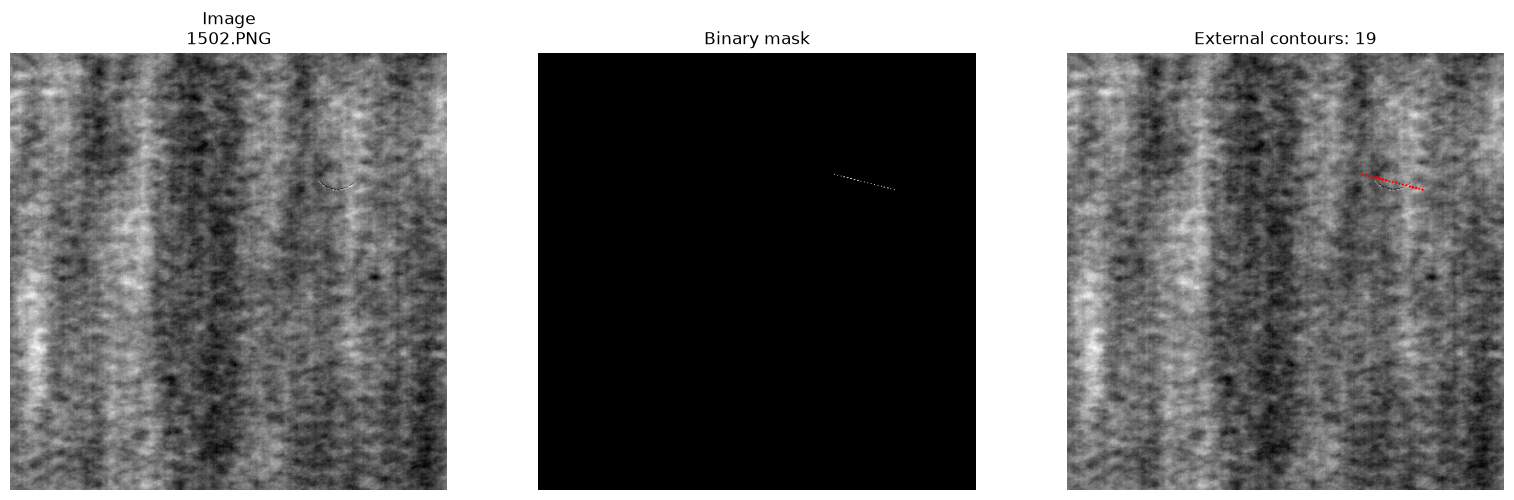

Class5 | test | 0282.PNG | empty=False | contours=1.0


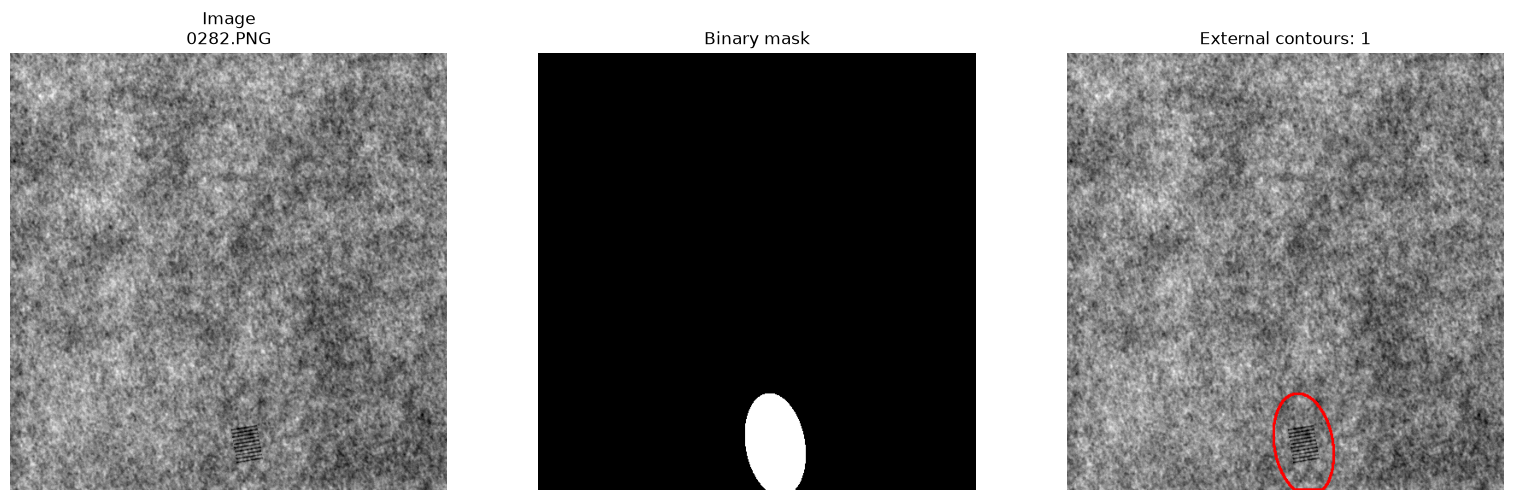

Class6 | train | 0761.PNG | empty=False | contours=1.0


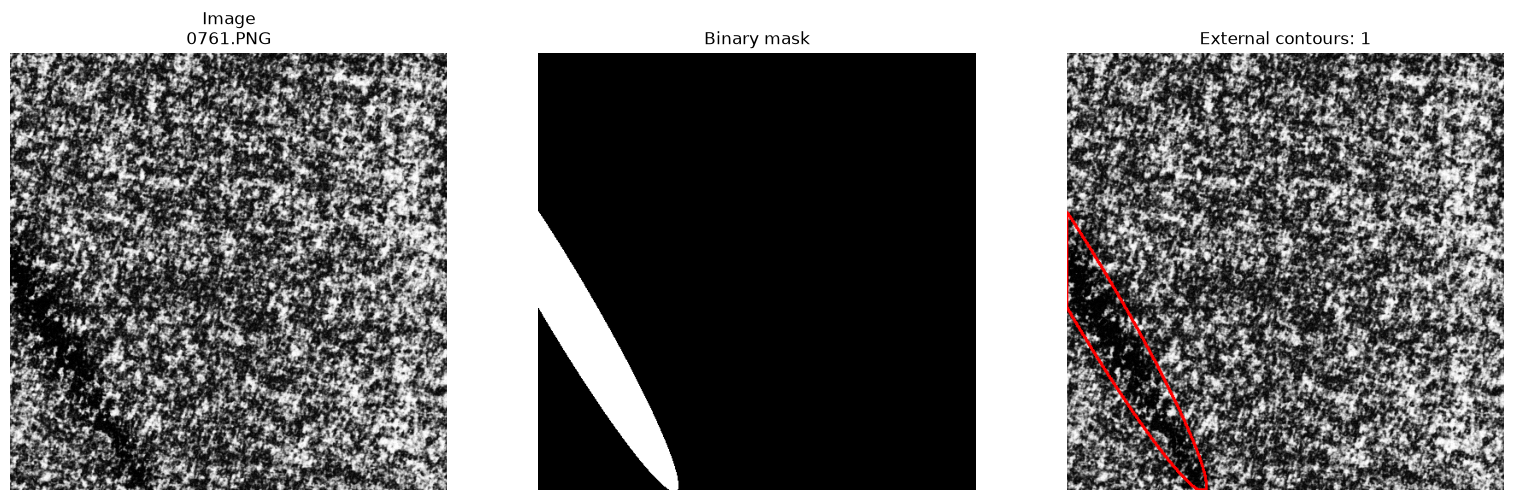

===== KolektorSDD2 =====
defect_region | train | 11444.png | empty=False | contours=3.0


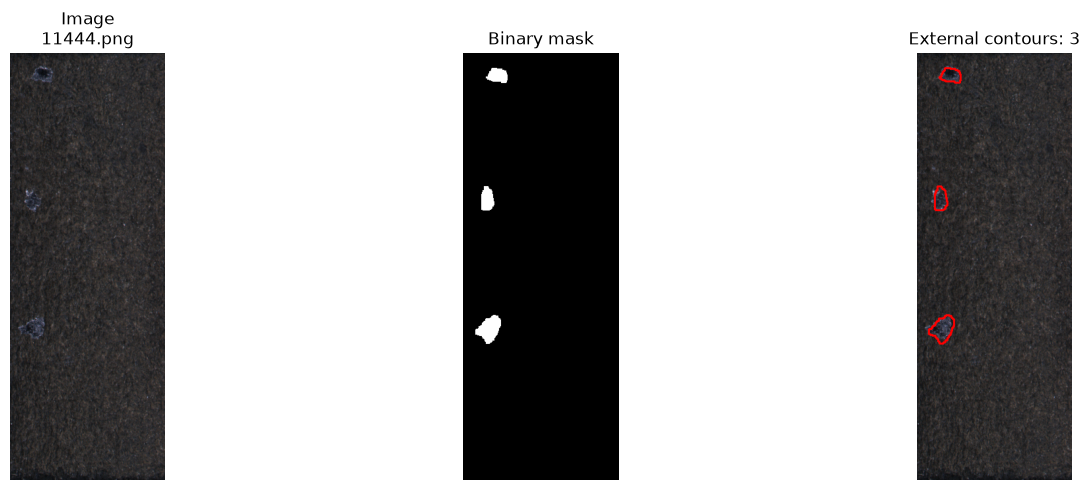

defect_region | train | 11973.png | empty=True | contours=0.0


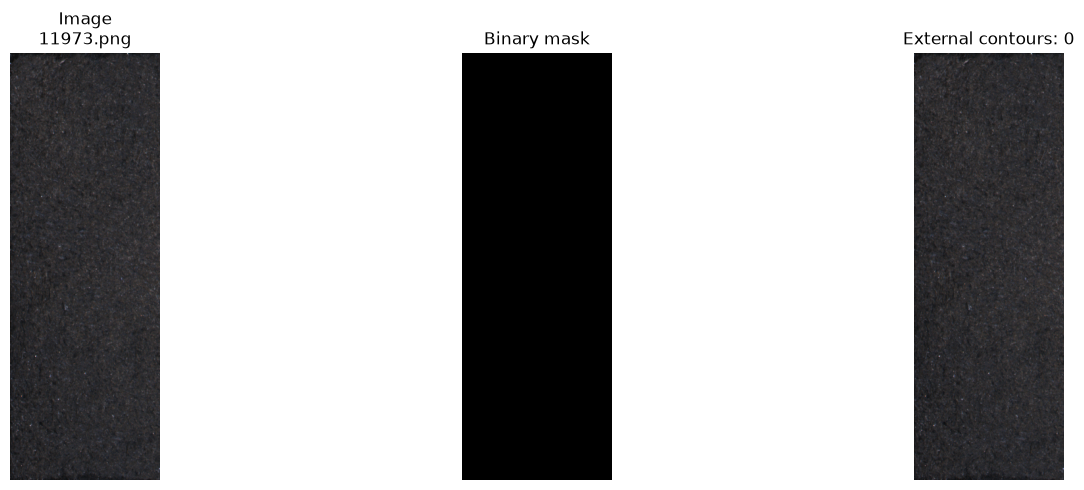

defect_region | test | 20337.png | empty=True | contours=0.0


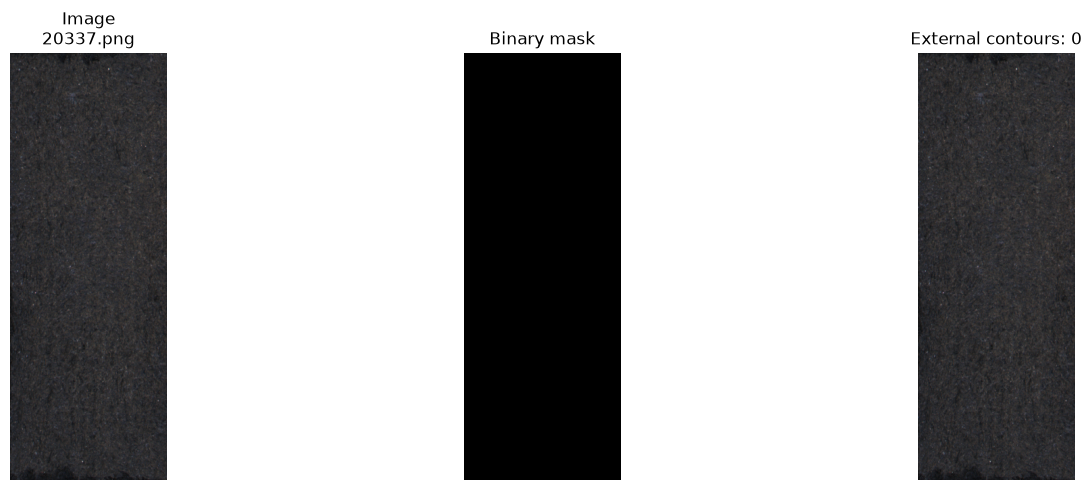

===== Magnetic Tile =====
MT_Break | nan | exp6_num_98402.jpg | empty=False | contours=30.0


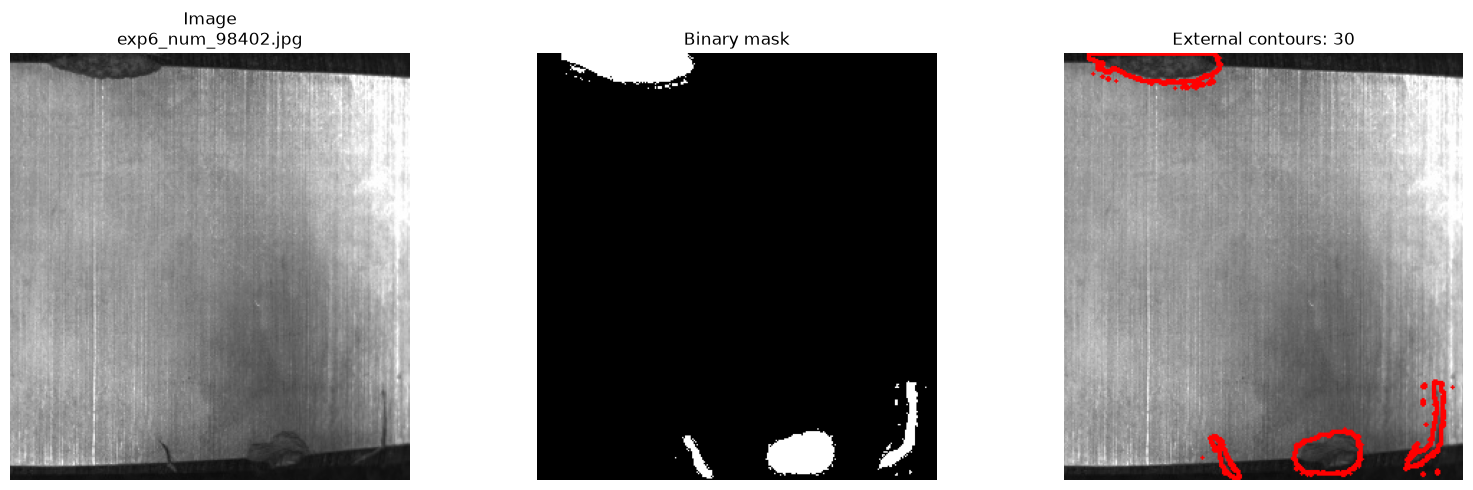

MT_Free | nan | exp3_num_337688.jpg | empty=True | contours=0.0


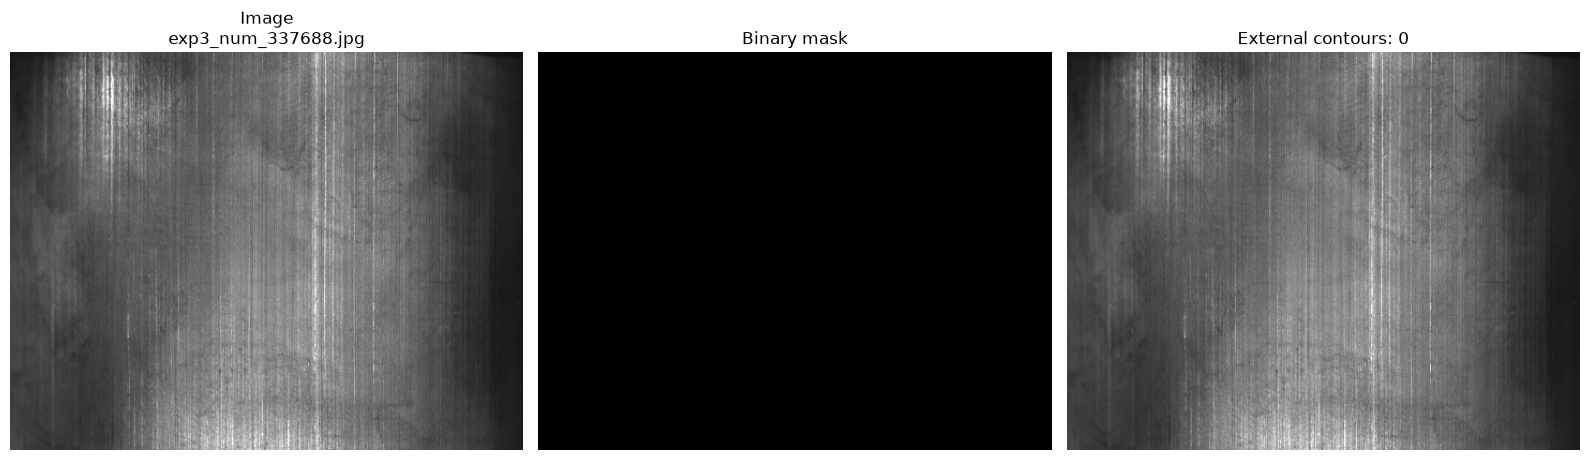

MT_Free | nan | exp2_num_10202.jpg | empty=True | contours=0.0


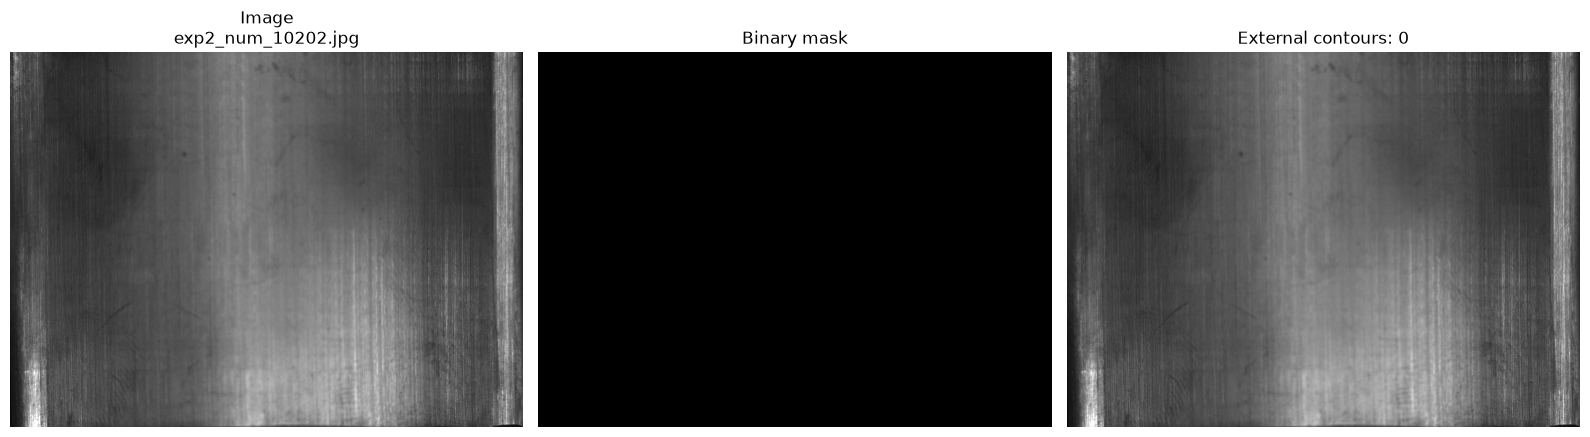

In [43]:
def show_samples(df, dataset_name, n=3, seed=SEED):
    candidates = df[(df['dataset'] == dataset_name) & df['mask_readable']].copy()
    if len(candidates) == 0:
        print(f'No readable samples found for {dataset_name}')
        return

    selected = []
    nonempty = candidates[~candidates['is_empty'].astype(bool)]
    multi = nonempty[nonempty['num_contours'] > 1]
    if len(multi):
        selected.append(multi.sort_values('num_contours', ascending=False).iloc[0])

    remaining = candidates.drop(index=[x.name for x in selected], errors='ignore')
    if len(remaining):
        sample_n = min(n - len(selected), len(remaining))
        if sample_n > 0:
            sampled = remaining.sample(sample_n, random_state=seed)
            selected.extend([row for _, row in sampled.iterrows()])

    print(f'===== {dataset_name} =====')
    for row in selected[:n]:
        print(f"{row['source_class']} | {row['split']} | {row['image_name']} | empty={row['is_empty']} | contours={row['num_contours']}")
        visualize_sample(row)

for dataset_name in ['DAGM', 'KolektorSDD2', 'Magnetic Tile']:
    show_samples(stats_df, dataset_name, n=3)


## 10b. DAGM class difficulty metadata

The provided DAGM characterization is preserved as analysis metadata only:

- **Low difficulty:** Classes 1, 2, 4 — uniform textures or gentle gradients with distinct, high-contrast defects.
- **Medium difficulty:** Classes 3, 5, 6 — regular patterns such as grids/meshes with subtle localized structural shifts.
- **High difficulty:** Classes 7, 8, 9, 10 — erratic/noisy or low-contrast backgrounds with faint/blurry defects.

This metadata does not alter labels or training data.

In [44]:
DAGM_DIFFICULTY = {
    'Class1': 'low', 'Class2': 'low', 'Class4': 'low',
    'Class3': 'medium', 'Class5': 'medium', 'Class6': 'medium',
    'Class7': 'high', 'Class8': 'high', 'Class9': 'high', 'Class10': 'high',
}

dagm_only = stats_df[stats_df['dataset'] == 'DAGM'].copy()
dagm_class_summary = (
    dagm_only.groupby('source_class', dropna=False)
    .agg(
        images=('image_name', 'count'),
        masks_found=('mask_readable', 'sum'),
        normal_images=('is_empty', lambda x: int(x.astype(bool).sum())),
        defective_images=('is_empty', lambda x: int((x.astype(bool) == False).sum())),
        mean_foreground_ratio=('foreground_ratio', 'mean'),
        median_foreground_ratio=('foreground_ratio', 'median'),
        max_contours=('num_contours', 'max'),
    )
    .reset_index()
)
dagm_class_summary['difficulty'] = dagm_class_summary['source_class'].map(DAGM_DIFFICULTY)
dagm_class_summary['defect_ratio'] = dagm_class_summary['defective_images'] / dagm_class_summary['images']
display(dagm_class_summary.sort_values('source_class'))


,source_class,images,masks_found,normal_images,defective_images,mean_foreground_ratio,median_foreground_ratio,max_contours,difficulty,defect_ratio
0,Class1,1150,150,0,1150,0.036605,0.030691,1.0,low,1.0
1,Class10,2300,300,0,2300,0.012608,0.010372,1.0,high,1.0
2,Class2,1150,150,0,1150,0.010673,0.008427,1.0,low,1.0
3,Class3,1150,150,0,1150,0.013990,0.011890,1.0,medium,1.0
4,Class4,1150,150,0,1150,0.027633,0.026785,1.0,low,1.0
5,Class5,1150,150,0,1150,0.019390,0.017908,1.0,medium,1.0
6,Class6,1150,150,0,1150,0.082393,0.085127,1.0,medium,1.0
7,Class7,2300,300,0,2300,0.037973,0.032175,1.0,high,1.0
8,Class8,2300,300,0,2300,0.005379,0.003527,19.0,high,1.0
9,Class9,2300,300,0,2300,0.003695,0.003641,1.0,high,1.0


## 11. Save inventory results

These CSV files are diagnostics, not training labels.

In [45]:
REPORT_DIR = DATA_ROOT / 'inventory_reports'
REPORT_DIR.mkdir(parents=True, exist_ok=True)

records_export = records_df.copy()
records_export['image_path'] = records_export['image_path'].astype(str)
records_export['mask_path'] = records_export['mask_path'].astype(str)
records_export.to_csv(REPORT_DIR / 'dataset_records.csv', index=False)

stats_export = stats_df.copy()
stats_export['mask_unique_values'] = stats_export['mask_unique_values'].astype(str)
stats_export['image_shape'] = stats_export['image_shape'].astype(str)
stats_export['mask_shape'] = stats_export['mask_shape'].astype(str)
stats_export.to_csv(REPORT_DIR / 'dataset_statistics.csv', index=False)
summary.to_csv(REPORT_DIR / 'dataset_summary.csv', index=False)
mask_summary.to_csv(REPORT_DIR / 'mask_summary.csv', index=False)
contour_stats_df.to_csv(REPORT_DIR / 'contour_statistics.csv', index=False)
contour_summary.to_csv(REPORT_DIR / 'contour_summary.csv', index=False)
dagm_class_summary.to_csv(REPORT_DIR / 'dagm_class_summary.csv', index=False)

print(f'Reports saved to: {REPORT_DIR}')


Reports saved to: datasets/inventory_reports


# Inventory checklist

Before moving to YOLO conversion, verify:

- [ ] All expected classes/directories are discovered.
- [ ] No unexpected image files are treated as masks.
- [ ] Image/mask pairs are complete.
- [ ] Image and mask dimensions match.
- [ ] Mask value distributions are understood.
- [ ] Empty masks are identified.
- [ ] Connected-component/contour counts look reasonable.
- [ ] Random image/mask/contour overlays are visually correct.
- [ ] Class/sample imbalance is quantified.

**Next notebook:** `02_prepare_yolo_segmentation.ipynb` — convert validated masks to YOLO polygon labels and generate dataset YAML files.